In [1]:
from langchain_openai import ChatOpenAI

# 모델 초기화
model = ChatOpenAI(model="gpt-4o-mini")
model.invoke('안녕하세요!')

AIMessage(content='안녕하세요! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 10, 'prompt_tokens': 10, 'total_tokens': 20, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_34a54ae93c', 'id': 'chatcmpl-C4HBoRIdJaJoLSczgD22BMYkSu0aF', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--c68a1810-9b46-4cba-b900-bf9eb6bb7f29-0', usage_metadata={'input_tokens': 10, 'output_tokens': 10, 'total_tokens': 20, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [2]:

from typing import Annotated # annotated는 타입 힌트를 사용할 때 사용하는 함수
from typing_extensions import TypedDict # TypedDict는 딕셔너리 타입을 정의할 때 사용하는 함수

from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

class State(TypedDict):	#①
    """
    State 클래스는 TypedDict를 상속받습니다.

    속성:
        messages (Annotated[list[str], add_messages]): 메시지들은 "list" 타입을 가집니다.   #②
       'add_messages' 함수는 이 상태 키가 어떻게 업데이트되어야 하는지를 정의합니다.  #③
        (이 경우, 메시지를 덮어쓰는 대신 리스트에 추가합니다)
    """
    messages: Annotated[list[str], add_messages]	#②

# StateGraph 클래스를 사용하여 State 타입의 그래프를 생성합니다.
graph_builder = StateGraph(State) #④

def generate(state: State):	#①
    """
    주어진 상태를 기반으로 챗봇의 응답 메시지를 생성합니다.

    매개변수:
    state (State): 현재 대화 상태를 나타내는 객체로, 이전 메시지들이 포함되어 있습니다.
		
    반환값:
    dict: 모델이 생성한 응답 메시지를 포함하는 딕셔너리. 
          형식은 {"messages": [응답 메시지]}입니다.
    """ 
    return {"messages": [model.invoke(state["messages"])]}	#②

graph_builder.add_node("generate", generate)	#③

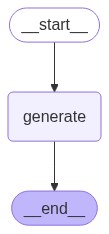

In [3]:
graph_builder.add_edge(START, "generate")
graph_builder.add_edge("generate", END)    

graph = graph_builder.compile()

from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception: 
    pass

In [4]:
response = graph.invoke({"messages": ["안녕하세요! 저는 이성용입니다"]})

print(type(response))
response

<class 'dict'>


{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다', additional_kwargs={}, response_metadata={}, id='aab31cb6-dd29-4a12-9f15-1381d51bb129'),
  AIMessage(content='안녕하세요, 이성용님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 15, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_62a23a81ef', 'id': 'chatcmpl-C4HCOFFc4aLH2Ixz6FaPoP9rU2gCZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--5137874a-81c7-4933-b714-2e6b64949d05-0', usage_metadata={'input_tokens': 15, 'output_tokens': 15, 'total_tokens': 30, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [5]:
response["messages"].append("제 이름을 아시나요?")
graph.invoke(response)

{'messages': [HumanMessage(content='안녕하세요! 저는 이성용입니다', additional_kwargs={}, response_metadata={}, id='aab31cb6-dd29-4a12-9f15-1381d51bb129'),
  AIMessage(content='안녕하세요, 이성용님! 어떻게 도와드릴까요?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 15, 'total_tokens': 30, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4o-mini-2024-07-18', 'system_fingerprint': 'fp_62a23a81ef', 'id': 'chatcmpl-C4HCOFFc4aLH2Ixz6FaPoP9rU2gCZ', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='run--5137874a-81c7-4933-b714-2e6b64949d05-0', usage_metadata={'input_tokens': 15, 'output_tokens': 15, 'total_tokens': 30, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}}),
  HumanMessage(content='제 이름을 

In [6]:
inputs = {"messages": [("human", "한국과 일본의 관계에 대해 자세히 알려줘")]}
for chunk, _ in graph.stream(inputs, stream_mode="messages"):
    print(chunk.content, end="")

한국과 일본의 관계는 역사적으로 복잡하고 다층적인 양상을 띠고 있습니다. 두 나라 사이의 관계는 문화, 경제, 정치 등 여러 분야에 걸쳐 있으며, 각각의 요소가 서로 영향을 미치고 있습니다.

### 1. 역사적 배경
- **일제 강점기 (1910-1945)**: 일본은 1910년에 한국을 강제로 병합하고, 35년간 식민지 지배를 시행했습니다. 이 시기에 많은 한국인들이 고통을 겪었고, 일본은 한국의 문화와 언어를 억압했습니다. 이 시기의 경험은 현재까지도 한국 사람들 사이에서 강한 감정을 불러일으키고 있습니다.

- **전후 관계**: 제2차 세계대전 이후, 일본은 한국과의 관계 개선을 위해 여러 가지 노력을 했습니다. 1965년 한일기본조약이 체결되어 양국 간의 외교 관계가 수립되었지만, 과거사 문제는 여전히 해결되지 않은 채 남아 있습니다.

### 2. 경제적 관계
- **무역**: 한국과 일본은 서로 중요한 무역 파트너국입니다. 일본은 한국의 주요 수출국 중 하나이며, 한국도 일본에 많은 상품을 수출합니다. 두 나라의 경제적 상호 의존성은 시간이 지남에 따라 더욱 깊어졌습니다.

- **기술 협력**: 일본의 기술력과 한국의 제조업 간의 협력도 중요한 관계의 한 축을 차지하고 있습니다.

### 3. 문화적 관계
- **문화 교류**: 한국과 일본은 문화적으로 많은 영향을 주고받았습니다. K-pop, 한국 드라마, 일본 애니메이션 등은 두 나라에서 큰 인기를 끌고 있습니다. 문화 교류는 양국 간의 관계를 부드럽게 만드는 중요한 요소입니다.

### 4. 정치적 관계
- **갈등과 협력**: 역사 문제 (예: 강제징용, 위안부 문제, 역사 교과서 문제 등)는 양국 간의 긴장을 증가시키는 요인이 됩니다. 그러나, 안보 문제에 대한 협력이 필요하기 때문에 양국은 군사적 및 외교적 협력도 지속하고 있습니다.

- **지역 안보**: 북한의 핵 프로그램과 같은 안보 위협에 대해 일본과 한국은 미국과의 삼각 동맹을 통해 협력하고 있습니다.

### 5. 현대의 

한국과 일본의 관계는 역사적으로 복잡하고 다층적인 양상을 띠고 있습니다. 두 나라 사이의 관계는 문화, 경제, 정치 등 여러 분야에 걸쳐 있으며, 각각의 요소가 서로 영향을 미치고 있습니다.

### 1. 역사적 배경
- **일제 강점기 (1910-1945)**: 일본은 1910년에 한국을 강제로 병합하고, 35년간 식민지 지배를 시행했습니다. 이 시기에 많은 한국인들이 고통을 겪었고, 일본은 한국의 문화와 언어를 억압했습니다. 이 시기의 경험은 현재까지도 한국 사람들 사이에서 강한 감정을 불러일으키고 있습니다.

- **전후 관계**: 제2차 세계대전 이후, 일본은 한국과의 관계 개선을 위해 여러 가지 노력을 했습니다. 1965년 한일기본조약이 체결되어 양국 간의 외교 관계가 수립되었지만, 과거사 문제는 여전히 해결되지 않은 채 남아 있습니다.

### 2. 경제적 관계
- **무역**: 한국과 일본은 서로 중요한 무역 파트너국입니다. 일본은 한국의 주요 수출국 중 하나이며, 한국도 일본에 많은 상품을 수출합니다. 두 나라의 경제적 상호 의존성은 시간이 지남에 따라 더욱 깊어졌습니다.

- **기술 협력**: 일본의 기술력과 한국의 제조업 간의 협력도 중요한 관계의 한 축을 차지하고 있습니다.

### 3. 문화적 관계
- **문화 교류**: 한국과 일본은 문화적으로 많은 영향을 주고받았습니다. K-pop, 한국 드라마, 일본 애니메이션 등은 두 나라에서 큰 인기를 끌고 있습니다. 문화 교류는 양국 간의 관계를 부드럽게 만드는 중요한 요소입니다.

### 4. 정치적 관계
- **갈등과 협력**: 역사 문제 (예: 강제징용, 위안부 문제, 역사 교과서 문제 등)는 양국 간의 긴장을 증가시키는 요인이 됩니다. 그러나, 안보 문제에 대한 협력이 필요하기 때문에 양국은 군사적 및 외교적 협력도 지속하고 있습니다.

- **지역 안보**: 북한의 핵 프로그램과 같은 안보 위협에 대해 일본과 한국은 미국과의 삼각 동맹을 통해 협력하고 있습니다.

### 5. 현대의 여러 쟁점
- **무역 갈등**: 2019년 일본의 수출 규제로 인해 한국과 일본 간의 무역 갈등이 심화되었습니다. 이는 양국의 경제에 큰 영향을 미쳤고, 정치적 갈등으로도 확대되었습니다.

- **시민 사회와의 연결**: 양국의 시민 사회에서는 양국 간의 평화와 친선을 위한 여러 활동이 이루어지고 있지만, 역사 문제에 대한 갈등은 여전히 큰 장애물로 남아 있습니다.

### 결론
한국과 일본의 관계는 과거의 역사적 상처에도 불구하고 경제적 및 문화적 교류가 이루어지고 있는 복잡한 양상이 있습니다. 정치적 갈등이 존재하더라도, 서로에 대한 이해와 협력이 관계 개선의 중요한 열쇠가 될 것입니다.